Contents:

1. Model
2. Learning rate schedule
3. Optimizer + partial

In [37]:
!unzip -q dataset.zip

# Data

- source: https://www.kaggle.com/datasets/imsparsh/flowers-dataset/data
- solution: https://www.kaggle.com/code/jasurbek03/task-1-cv-assignment-2
- manually set lr

In [ ]:
!pip install gdown
!gdown https://drive.google.com/uc?id=1XLMwhTklIgCJOiJutwmzvqd67LgeoM5x
!mkdir -p data/kaggle-1 data/kaggle-2
!unzip -q kaggle-1.zip -d data/kaggle-1
!unzip -q kaggle-2.zip -d data/kaggle-2

Downloading...
From (original): https://drive.google.com/uc?id=138g9sbWRZ7WaTACokL-Gjzu0kAfmJBZQ
From (redirected): https://drive.google.com/uc?id=138g9sbWRZ7WaTACokL-Gjzu0kAfmJBZQ&confirm=t&uuid=9976bea3-fa54-44b9-ac9a-fc6aec199b53
To: /content/kaggle-1.zip
100% 215M/215M [00:05<00:00, 42.3MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1XLMwhTklIgCJOiJutwmzvqd67LgeoM5x
From (redirected): https://drive.google.com/uc?id=1XLMwhTklIgCJOiJutwmzvqd67LgeoM5x&confirm=t&uuid=75a72f61-32fc-425c-af3e-dc3a2f6f58ab
To: /content/kaggle-2.zip
100% 239M/239M [00:04<00:00, 57.9MB/s]


In [ ]:
!sudo apt-get install tree
!tree data --filelimit 20

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 49 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 1s (87.3 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tree.
(Reading database ... 124561 files and directories currently instal

# Dataloader

In [ ]:
from glob import glob
from pathlib import Path
import os

import numpy as np
import cv2
from skimage.io import imread

import torch
import torch.utils.data as data  # dataset shuffling, sample batching, ...
from torch import nn  # neural network layers
import torchvision.transforms as T  # augmentation

import matplotlib.pyplot as plt
import pickle # Save/load patch locations.

NUM_CLASSES = 16

def imginfo(img):
    print(type(img), img.dtype, img.shape, img.min(), img.max())

In [ ]:
np.random.randint(low=0, high=15)

12

In [ ]:
from torchvision import transforms
from PIL import Image

class FlowerDataset(data.Dataset):
    def _load_image(self, idx) -> np.ndarray:
        return np.array(Image.open(self.paths[idx][0])).astype('float32') / 255.0
        return imread(self.paths[idx][0]).astype('float32') / 255.0
        #return Image.open(path).convert("RGB")

    def __init__(self):
        self.paths = [] # string data/image.jpg -> int flower class

        # Add path of each image with gt label
        dataset_path = Path("data/kaggle-2/flowers")
        flower_paths = sorted(dataset_path.iterdir())
        self.class_str = [path.name for path in flower_paths] # flower class index to string name
        for idx, flower in enumerate(flower_paths):
            images = flower.iterdir()
            for image in images:
                path_gt = (str(image), idx)
                self.paths.append(path_gt)

    def __getitem__(self, idx):
        idx = np.random.randint(low=0, high=len(self.paths))

        image = self._load_image(idx)
        # fix image shape, must be (h, w, RGB)
        if len(image.shape) == 2: # (h, w)
            image = image[:, :, np.newaxis]
        if image.shape[2] == 1:
            image = np.tile(image, 3)
        elif image.shape[2] > 3:
            image = image[:, :, :3]


        train_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),

            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])


        val_transform = transforms.Compose([

            transforms.ToTensor(),
            transforms.Resize((224, 224)),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

        image = train_transform(image) # (c, h, w)


        label = self.paths[idx][1]

        return image, label

    def __len__(self):
        return 2000 # len(self.paths)

In [ ]:
dataset = FlowerDataset()

print("flower classes:", dataset.class_str)
print("dataset size:", len(dataset.paths))

flower classes: ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'daffodil', 'dandelion', 'iris', 'magnolia', 'rose', 'sunflower', 'tulip', 'water_lily']
dataset size: 15740


In [ ]:
imginfo(dataset._load_image(0))
imginfo(dataset._load_image(5000))

image, gt = dataset[0]
imginfo(image)
print("class", gt)

<class 'numpy.ndarray'> float32 (256, 256, 3) 0.0 1.0
<class 'numpy.ndarray'> float32 (256, 256, 3) 0.0 1.0
<class 'torch.Tensor'> torch.float32 torch.Size([3, 224, 224]) tensor(-1.9385) tensor(2.0939)
class 11


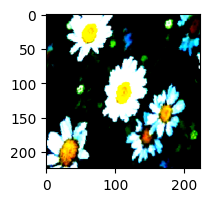

In [ ]:
def display_train_image(idx):
    image, gt = dataset[idx]
    plt.figure(figsize=(2, 2))
    plt.imshow(image.permute(1, 2, 0))
    plt.show()

display_train_image(0)

# Model

hint: table of pretrained pytorch classifiers

In [ ]:
!pip install timm torch-summary

In [ ]:
from torchvision.models import resnet18, get_model
import timm
import torchsummary

In [ ]:
model = get_model("mobilenet_v3_small", weights="MobileNet_V3_Small_Weights.IMAGENET1K_V1")
torchsummary.summary(model, (3, 224, 224), device="cpu")

print("model layers:", len( list(model.children()) ))
backbone, avgpool, head = model.children()

print("backbone layers:", len( list(backbone.children()) ))
backbone_layers = list(backbone.children())

in_feat = 40
num_classes = 17
backbone_reduced = nn.Sequential(
    *backbone_layers[:6],
    nn.Sequential(avgpool, nn.Flatten()),
    nn.Linear(in_feat, num_classes))

torchsummary.summary(backbone_reduced, (3, 224, 224), device="cpu")
print()

In [13]:
class FlowerClassifier(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.type = "resnet18"

        if self.type == "resnet18":
            self.backbone = get_model("efficientnet_v2_s", weights="EfficientNet_V2_S_Weights.IMAGENET1K_V1")
            in_feat = self.backbone.classifier[1].in_features
            self.backbone.classifier[1] = nn.Identity()
            for param in self.backbone.parameters():
                param.requires_grad = True
            self.fc = nn.Linear(in_feat, num_classes)

        elif self.type == "vit":
            self.vit = timm.create_model('vit_base_patch16_224', pretrained=True)
            for param in self.vit.parameters():
                param.requires_grad = False
            print("VIT features", self.vit.head.in_features)
            self.fc = nn.Linear(self.vit.head.in_features, num_classes)
            self.vit.head = nn.Identity()


    def forward(self, images):
        if self.type == "resnet18":
            x = self.backbone(images) # (b, c, h, w) -> (b, 512)
            x = self.fc(x) # (b, 512) -> (b, 1)
        elif self.type == "vit":
            x = self.vit(images)
            x = self.fc(x)

        return x

model = FlowerClassifier(NUM_CLASSES)

NameError: name 'nn' is not defined

In [ ]:
print(model.backbone)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

In [ ]:
import torchsummary


torchsummary.summary(model, (3, 224, 224), device="cpu")
print()

Layer (type:depth-idx)                        Output Shape              Param #
├─EfficientNet: 1-1                           [-1, 1280]                --
|    └─Sequential: 2-1                        [-1, 1280, 7, 7]          --
|    |    └─Conv2dNormActivation: 3-1         [-1, 24, 112, 112]        696
|    |    └─Sequential: 3-2                   [-1, 24, 112, 112]        10,464
|    |    └─Sequential: 3-3                   [-1, 48, 56, 56]          303,552
|    |    └─Sequential: 3-4                   [-1, 64, 28, 28]          589,184
|    |    └─Sequential: 3-5                   [-1, 128, 14, 14]         917,680
|    |    └─Sequential: 3-6                   [-1, 160, 14, 14]         3,463,840
|    |    └─Sequential: 3-7                   [-1, 256, 7, 7]           14,561,832
|    |    └─Conv2dNormActivation: 3-8         [-1, 1280, 7, 7]          330,240
|    └─AdaptiveAvgPool2d: 2-2                 [-1, 1280, 1, 1]          --
|    └─Sequential: 2-3                        [-1, 1280

Check that the model works and the output has correct shape.

In [ ]:
image = dataset[0][0]
image = image[None, ...]
print("training sample")
imginfo(image)
print("model output:", model(image))

training sample
<class 'torch.Tensor'> torch.float32 torch.Size([1, 3, 224, 224]) tensor(-2.1179) tensor(2.3892)
model output: tensor([[ 0.0374,  0.0248, -0.1005, -0.2869,  0.0174, -0.0173, -0.0511, -0.0136,
          0.0414, -0.0515,  0.0550,  0.2157, -0.0168, -0.0905, -0.2061,  0.1499]],
       grad_fn=<AddmmBackward0>)


# Training

Learning rate per epoch:


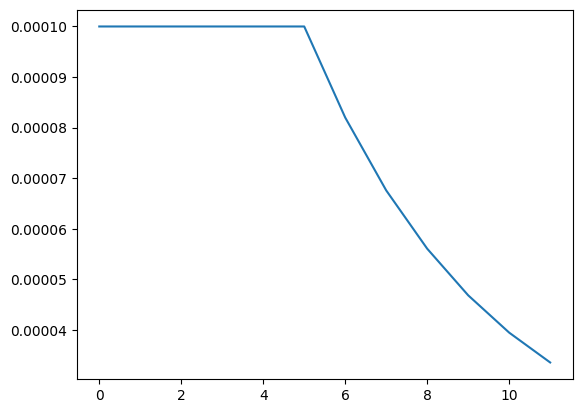

In [ ]:
# hint: tpus in colab
EPOCHS = 12

start_lr = 0.0001 # 1e-4
min_lr = 0.00001 # 1e-4
max_lr = 0.0001 # 5e-4
rampup_epochs = 5 # 5
sustain_epochs = 0
exp_decay = .8

def lrfn(epoch):
  if epoch < rampup_epochs:
    return (max_lr - start_lr)/rampup_epochs * epoch + start_lr
  elif epoch < rampup_epochs + sustain_epochs:
    return max_lr
  else:
    return (max_lr - min_lr) * exp_decay**(epoch-rampup_epochs-sustain_epochs) + min_lr

rang = np.arange(EPOCHS)
y = [lrfn(x) for x in rang]
plt.plot(rang, y)
print('Learning rate per epoch:')

In [ ]:
from tqdm import tqdm

DEVICE = "cuda"

#import torch_xla.core.xla_model as xm
#DEVICE = xm.xla_device()

def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    best_train_acc = 0.0
    best_val_acc = 0.0
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        # Training
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for g in optimizer.param_groups:
            g['lr'] = lrfn(epoch)


        for inputs, labels in tqdm(train_loader):
            # (b, c, h, w), (b)
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_accs.append(train_acc)


        # Validation
        if False:
            model.eval()
            running_loss = 0.0
            correct = 0
            total = 0

            with torch.no_grad():
                for inputs, labels in val_loader:
                    inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)

                    running_loss += loss.item()
                    _, predicted = outputs.max(1)
                    total += labels.size(0)
                    correct += predicted.eq(labels).sum().item()

            val_loss = running_loss / len(val_loader)
            val_acc = 100. * correct / total
            val_losses.append(val_loss)
            val_accs.append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}:')
        print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
        #print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

        if train_acc > best_train_acc:
            best_train_acc = train_acc
            save_data = {
                "fc": model.fc
            }
            torch.save(save_data, "fc.pth")

        if False:
            if val_acc > best_val_acc:
                best_val_acc = val_acc
                torch.save(model.state_dict(), f'best_{model.__class__.__name__}.pth')

    return train_losses, train_accs, val_losses, val_accs

In [ ]:
def main():
  load_ckpt = True

  num_epochs = 20
  batch_size = 64
  workers = 2

  dataset = FlowerDataset()

  criterion = nn.CrossEntropyLoss()
  model = FlowerClassifier(NUM_CLASSES).to(DEVICE)
  if load_ckpt:
      ckpt = torch.load("fc.pth", map_location=torch.device(DEVICE))
      model.fc = ckpt["fc"]

  optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)


  train_loader = data.DataLoader(dataset, batch_size=batch_size, shuffle=True,
      num_workers=workers, drop_last=False, pin_memory=False)


  train(model, train_loader, train_loader, criterion, optimizer, num_epochs)


main()

<ipython-input-16-5caa8705ad93>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load("fc.pth", map_location=torch.device(DEVICE))
100%|██████████| 32/32 [00:3

Epoch 1/20:
Train Loss: 0.5913, Train Acc: 81.55%


100%|██████████| 32/32 [00:26<00:00,  1.22it/s]


Epoch 2/20:
Train Loss: 0.3363, Train Acc: 90.65%


100%|██████████| 32/32 [00:25<00:00,  1.27it/s]


...

Epoch 18/20:
Train Loss: 0.0800, Train Acc: 97.70%


100%|██████████| 32/32 [00:26<00:00,  1.23it/s]


Epoch 19/20:
Train Loss: 0.0834, Train Acc: 97.65%


100%|██████████| 32/32 [00:26<00:00,  1.22it/s]

Epoch 20/20:
Train Loss: 0.0865, Train Acc: 97.60%


# STOP

In [ ]:
DEVICE = "cuda" # "cpu" or "cuda"
PRINT_FREQ = 50 # how frequently to print training status
VAL_FREQ = 250 # how frequently to run validation

from torch.utils.tensorboard import SummaryWriter

class Logger:
    def __init__(self, path='runs/logbook', total_steps=0):
        self.total_steps = total_steps
        self.running_loss = {}
        self.writer = None
        self.writer_path = path

    def _print_training_status(self):
        # write average values to tensorboard
        if self.writer is None:
            self.writer = SummaryWriter(self.writer_path)
        for key in self.running_loss:
            self.writer.add_scalar(key, self.running_loss[key]/PRINT_FREQ, self.total_steps)
            self.running_loss[key] = 0.0

    def push(self, metrics):
        # sum new metric values for averaging
        self.total_steps += 1

        for key in metrics:
            if key not in self.running_loss:
                self.running_loss[key] = 0.0
            self.running_loss[key] += metrics[key]

        if self.total_steps % PRINT_FREQ == PRINT_FREQ - 1:
            self._print_training_status()
            self.running_loss = {}

    def write_dict(self, results):
        # write values to tensorboard without averaging
        if self.writer is None:
            self.writer = SummaryWriter(self.writer_path)
        for key in results:
            self.writer.add_scalar(key, results[key], self.total_steps)

    def close(self):
        self.writer.close()

In [ ]:
import time
import datetime as dt

def calc_validation_score():
    model.train(False)
    errors = []
    for image_id in val_image_ids:
        errors.append(calc_error(image_id))
    model.train(True)
    return np.mean(np.array(errors))

def train(model, train_dl, optimizer, logger, visualize_list, train_steps):
    """
    Main training loop. Load training data, run model forward and backward pass,
    print training status, run validation.
    """
    start = time.time()
    model.to(DEVICE)

    softmax = nn.Softmax(dim=-1).to(DEVICE)
    eps = torch.tensor(0.0001).to(DEVICE)
    binary_cross_entropy = nn.BCELoss(reduction="sum")

    print("Training steps:", train_steps)

    while True:
        model.train(True)  # set training mode
        dataloader = train_dl
        step = 0
        ema_loss = 0.0
        start_time = time.time()

        # iterate over data
        for left_patch, right_strip, labels in dataloader:
            step += 1

            # moving tensors to GPU
            # tensor shape b h w c -> b c h w
            left_patch = left_patch.to(DEVICE).permute(0, 3, 1, 2).float().contiguous() # contiguous speeds up 2-4x
            right_strip = right_strip.to(DEVICE).permute(0, 3, 1, 2).float().contiguous()
            labels = labels.to(DEVICE).contiguous() # shape=(b w)

            # forward pass
            optimizer.zero_grad()

            # Run model on left_patch, right_strip. Compute loss with labels.

            # your code here
            # vvvvvvvvvvvvvv

            patch_feat = model(left_patch) # shape=(b c 1 1)
            strip_feat = model(right_strip) # shape=(b c 1 w)
            inner_prod = torch.sum(patch_feat * strip_feat, dim=1) # broadcasting. shape=(b 1 w)
            inner_prod = torch.squeeze(inner_prod) # remove all dimensions of size 1. shape=(b w)
            target = softmax(inner_prod) # softmax by last dimension
            target = target * (1 - eps * 2) + eps # do not allow too high loss
            target_view = target.view(-1).float() # BCE loss does not allow complex shape
            labels_view = labels.view(-1).float()
            loss = binary_cross_entropy(target_view, labels_view)
            # loss = -torch.sum(labels * torch.log(target + eps) + (1 - labels) * torch.log(1 - target + eps))

            # ^^^^^^^^^^^^^^

            # backward pass
            loss.backward()
            optimizer.step()

            show_loss = loss.detach().cpu().numpy()
            ema_loss = show_loss * (2/(1+step)) + ema_loss * (1-2/(1+step))
            metrics = {
                'cross_entropy_loss': show_loss
            }
            logger.push(metrics)

            if step % PRINT_FREQ == PRINT_FREQ - 1:
                print("step: {}, EMA BCE loss: {:.2f}, step time: {:.2f}".format(step,
                                                                                 ema_loss, (time.time() - start_time) / step))
                left_img = imread(left_image_paths[0]).astype(np.float64) / 255.0
                right_img = imread(right_image_paths[0]).astype(np.float64) / 255.0
                out_img = evaluate_model(model, left_img, right_img)
                visualize_list.append((out_img, step))

            if step % VAL_FREQ == VAL_FREQ - 1:
                val_error = calc_validation_score()
                metrics = {
                    'val_error_percent': val_error
                }
                logger.write_dict(metrics)
                print("validation error: {:.2f}".format(val_error))

            if step > train_steps:
                return

    return train_loss, valid_loss, disp_vis

experiment = dt.datetime.now().strftime("%H%M%S")
logger = Logger(path="runs/logbook-" + experiment)
visualize_list = [] # [(disparity image, steps performed), ...]
model = PatchModel()
print("Parameters:", sum(p.numel() for p in model.parameters()))
optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
train_loader = data.DataLoader(train_dataset, batch_size=128,
        pin_memory=False, shuffle=True, num_workers=2, drop_last=True)

train(model, train_loader, optimizer, logger, visualize_list, train_steps=500)

# Augmentation

In [ ]:
import torchvision.transforms as T

torch.manual_seed(0)

def display_train_patches(idx):
    left_patch, right_strip_patch, labels = train_dataset[idx]
    print(left_patch.shape)

    for i in range(10):
        t = torch.clone(right_strip_patch.permute(2, 0, 1))

        # your code here
        # vvvvvvvvvvvvvv
        photo_aug = T.Compose([
                   T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.5/3.14),
                   T.GaussianBlur(7)
        ])
        t = photo_aug(t)
        # ^^^^^^^^^^^^^^

        img = t.permute(1, 2, 0)

        plt.figure(figsize=(15, 15))
        plt.imshow(img)
        plt.show()

display_train_patches(0)